### Exercício 1

In [1]:
import numpy as np

def maior(matriz):
    linhas = len(matriz[:,0])
    colunas = len(matriz[0,:])
    maior = 0
    for i in range(linhas):
        for j in range(colunas):
            if maior < matriz[i,j]:
                maior = matriz[i,j]
    return maior

def Assembly(conec, C):
    nv = maior(conec) # numero de nós
    nc = len(conec[:,0])  # numero de canos
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1-1,n1-1] = A[n1-1,n1-1] + C[k]
        A[n2-1,n2-1] = A[n2-1,n2-1] + C[k]
        A[n1-1,n2-1] = - C[k]
        A[n2-1,n1-1] = - C[k]
    return A

conec = np.array([[1,2],[2,3],[3,4],[4,5],[5,2],[5,3],[5,1]])
C = np.array([2,2,1,2,1,2,2])
A = Assembly(conec, C)
print(A)

[[ 4. -2.  0.  0. -2.]
 [-2.  5. -2.  0. -1.]
 [ 0. -2.  5. -1. -2.]
 [ 0.  0. -1.  3. -2.]
 [-2. -1. -2. -2.  7.]]


### Exercício 2

In [2]:
import numpy as np

def maior(matriz):
    linhas = len(matriz[:,0])
    colunas = len(matriz[0,:])
    maior = 0
    for i in range(linhas):
        for j in range(colunas):
            if maior < matriz[i,j]:
                maior = matriz[i,j]
    return maior

def Assembly(conec, C):
    nv = maior(conec) # numero de nós
    nc = len(conec[:,0])  # numero de canos
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1-1,n1-1] = A[n1-1,n1-1] + C[k]
        A[n2-1,n2-1] = A[n2-1,n2-1] + C[k]
        A[n1-1,n2-1] = - C[k]
        A[n2-1,n1-1] = - C[k]
    return A

def SolveNetwork(conec, natm, nB, QB, C):
    Atilde = Assembly(conec, C)
    Atilde[natm-1, :] = 0
    Atilde[natm-1, natm-1] = 1
    print(Atilde)
    nv = len(Atilde[0,:])
    b = np.zeros(shape=(nv,1))
    b[nB-1,0] = QB
    print(b)
    pressure = np.linalg.solve(Atilde, b)
    return pressure

def format(pressure):
    form = []
    for p in pressure:
        form.append(f'{p[0]:.6f}')
    return form

conec = np.array([[1,2],[2,3],[3,4],[4,5],[5,2],[5,3],[5,1]])
C = np.array([2,2,1,2,1,2,2])
A = Assembly(conec, C)
pressao = SolveNetwork(conec, 3, 1, 3, C)
print(format(pressao))

[[ 4. -2.  0.  0. -2.]
 [-2.  5. -2.  0. -1.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0. -1.  3. -2.]
 [-2. -1. -2. -2.  7.]]
[[3.]
 [0.]
 [0.]
 [0.]
 [0.]]
['1.397727', '0.681818', '0.000000', '0.409091', '0.613636']


### Exercício 3

In [3]:
# Lei de perda de pressão em função da vazão:
# delta p_k = p_i - p_j = rho_k * L_k * Q_k
#rho_k == constante de resistência
# L_k é o comprimento do cano
# C_k é a condutância = 1/(rho_k * L_k)
# Logo, Q_k = C_k * delta Pressão

# multiplicando Kij com a matriz resposta das pressões vc obtém vazão
# Porém, vc precisa da diferença entre as pressões dos nós que estão interligados por um mesmo cano
# Cada linha de D mostra que se deve multiplicar a matriz de pressão
# somente 2 vezes (diferente de 0), a fim de gerar uma diferença entre essas pressões
# vê-se que cada linha tem 1 (p_coluna1) e -1 (p_coluna2), 
# sendo que p_coluna1 e p_coluna2 são as pressões dos nós interligados
# pelo cano_num_da_linha
# se a vazão for negativa, significa que o fluxo está contrário ao estipulado antes

import numpy as np

def matrizK(C):
    nc = len(C)
    k = np.zeros(shape=(nc,nc))
    for i in range(nc):
        k[i,i] = C[i]
    return k

def matrizD(conec):
    nv = np.max(conec)
    nc = len(conec[:,0]) 
    D = np.zeros(shape=(nc,nv))
    for k in range(nc):
        for j in range(nv):
            if j == conec[k,0] - 1:
                D[k,j] = 1
            if j == conec[k,1] - 1:
                D[k,j] = -1
    return D

C = np.array([2,2,1,2,1,2,2])
conec = np.array([[1,2],[2,3],[3,4],[4,5],[5,2],[5,3],[5,1]])
k = matrizK(C)
d = matrizD(conec)
print(k, "\n")
print(d)

Q = k @ d @ pressao
print(Q)

[[2. 0. 0. 0. 0. 0. 0.]
 [0. 2. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 2. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 2. 0.]
 [0. 0. 0. 0. 0. 0. 2.]] 

[[ 1. -1.  0.  0.  0.]
 [ 0.  1. -1.  0.  0.]
 [ 0.  0.  1. -1.  0.]
 [ 0.  0.  0.  1. -1.]
 [ 0. -1.  0.  0.  1.]
 [ 0.  0. -1.  0.  1.]
 [-1.  0.  0.  0.  1.]]
[[ 1.43181818]
 [ 1.36363636]
 [-0.40909091]
 [-0.40909091]
 [-0.06818182]
 [ 1.22727273]
 [-1.56818182]]


### Exercício 4

In [4]:
import numpy as np

def Assembly(conec, C):
    nv = np.max(conec) # numero de nós
    nc = len(conec[:,0])  # numero de canos
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1-1,n1-1] = A[n1-1,n1-1] + C[k]
        A[n2-1,n2-1] = A[n2-1,n2-1] + C[k]
        A[n1-1,n2-1] = - C[k]
        A[n2-1,n1-1] = - C[k]
    return A

def SolveNetwork(conec, natm, nB, QB, C):
    Atilde = Assembly(conec, C)
    Atilde[natm-1, :] = 0
    Atilde[natm-1, natm-1] = 1
    nv = len(Atilde[0,:])
    b = np.zeros(shape=(nv,1))
    b[nB-1,0] = QB
    pressure = np.linalg.solve(Atilde, b)
    return pressure

def matrizK(C):
    nc = len(C)
    k = np.zeros(shape=(nc,nc))
    for i in range(nc):
        k[i,i] = C[i]
    return k

def matrizD(conec):
    nv = np.max(conec)
    nc = len(conec[:,0]) 
    D = np.zeros(shape=(nc,nv))
    for k in range(nc):
        for j in range(nv):
            if j == conec[k,0] - 1:
                D[k,j] = 1
            if j == conec[k,1] - 1:
                D[k,j] = -1
    return D

conec = np.array([[1,2],[2,3],[3,4],[4,5],[5,2],[5,3],[5,1]])
C = np.array([2,2,1,2,1,2,2])
A = Assembly(conec, C)
pressao = SolveNetwork(conec, 3, 1, 3, C)
k = matrizK(C)
d = matrizD(conec)

pressao_transp = np.transpose(pressao)
d_transp = np.transpose(d)

print(float(pressao_transp @ d_transp @ k @ d @ pressao))


4.193181818181819


### Exercício 5

[4.40748818 3.55642676 3.08930348 2.76648358 2.51625845 2.31270072
 2.14676478 2.017326   1.9272673  1.88075497 3.88148258 3.41778243
 3.03719393 2.7402688  2.49940632 2.29911508 2.13358525 2.00310542
 1.91154222 1.86395886 3.52292425 3.24912557 2.9548726  2.69380919
 2.46790348 2.27297671 2.10774877 1.9748316  1.87993553 1.82997986
 3.26323768 3.08785497 2.86056615 2.63465373 2.42521379 2.23611376
 2.07024452 1.93282796 1.83210035 1.77796132 3.06688375 2.94532824
 2.76576266 2.56954988 2.37517913 2.19086192 2.02246569 1.87757551
 1.76744153 1.70639256 2.91442486 2.8237496  2.67697067 2.50378085
 2.32151403 2.13986084 1.96619856 1.80977223 1.68505757 1.61277835
 2.79470983 2.72243061 2.59771595 2.44128962 2.26762734 2.08597415
 1.90370733 1.7305175  1.58373858 1.49306331 2.70109561 2.64004665
 2.52991266 2.38502249 2.21662626 2.03230905 1.8379383  1.64172551
 1.46215993 1.34060443 2.62952686 2.57538782 2.47466022 2.33724366
 2.17137441 1.98227439 1.77283445 1.54692203 1.31963321 1.1442

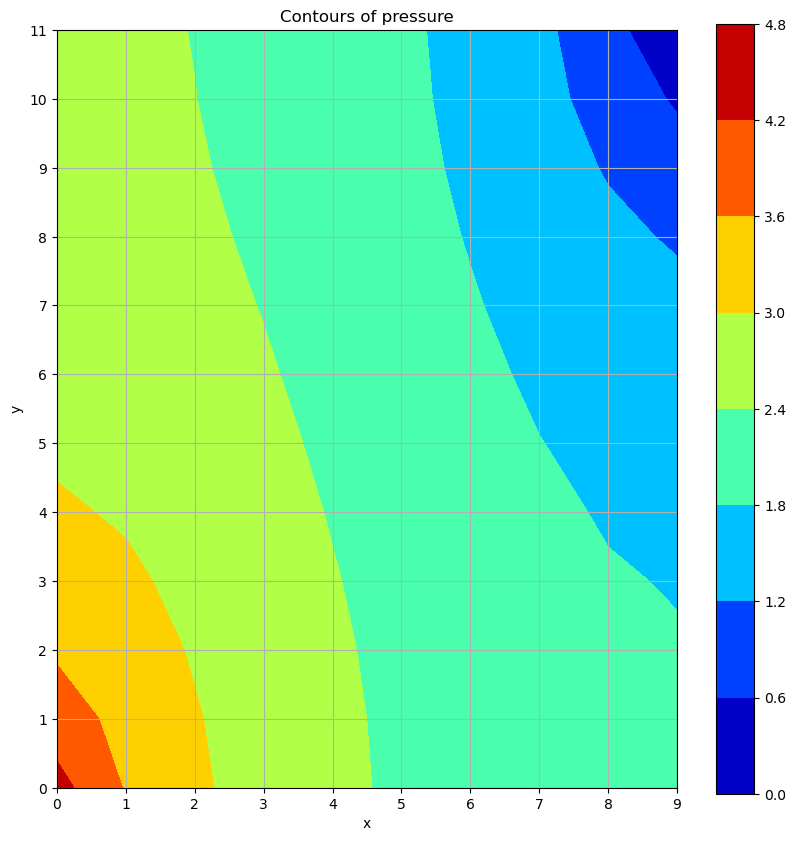

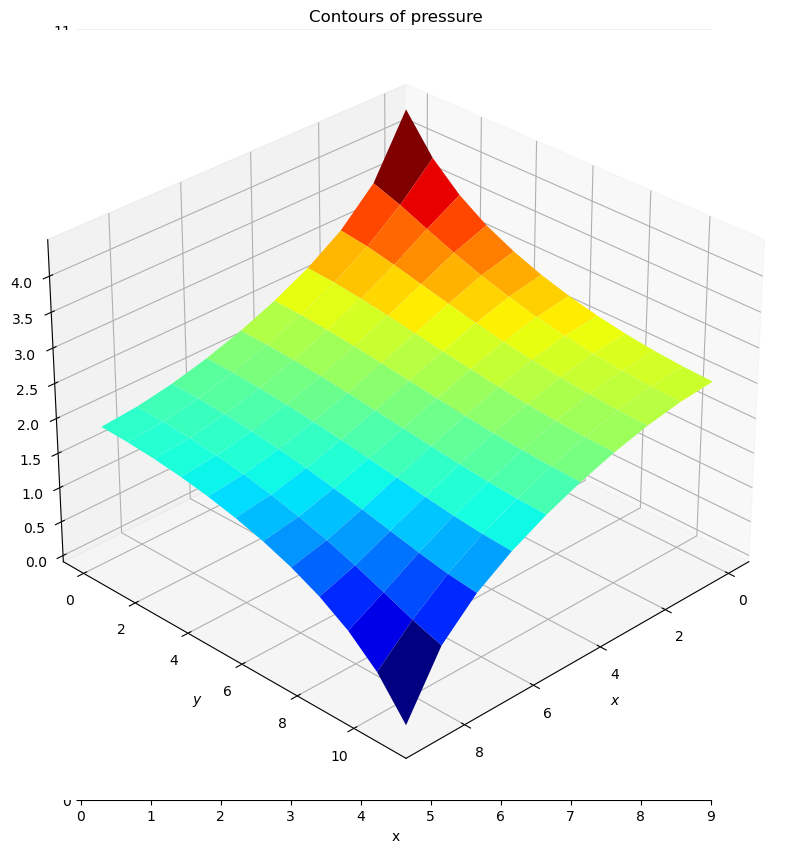

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def GeraRede(nx,ny,CH,CV):
    nv = nx*ny
    nc = (nx-1)*ny + (ny-1)*nx
    
    coord = np.zeros(shape=(nv,2))

    for i in range(nx):
      for j in range(ny):
        ig = i + j*nx
        coord[ig,0] = i
        coord[ig,1] = j

    conec = np.zeros(shape=(nc,2), dtype=int)
    C = np.zeros(nc)
    
    # Loop sobre canos horizontais
    for j in range(ny):
        for i in range(nx-1):
          k = j*(nx-1) + i
          conec[k,0] = j*nx + i
          conec[k,1] = j*nx + i+1
          C[k] = CH

    # Loop sobre canos verticais
    for i in range(nx):
      for j in range(ny-1):
          k = (nx-1)*ny + j*nx + i
          conec[k,0] = i + j*nx
          conec[k,1] = i + (j+1)*nx
          C[k] = CV

    return nv, nc, conec, C, coord

def Assembly(conec, C):
    nv = np.max(conec) + 1 # numero de nós 
    #coloquei +1 pq neste caso, começa em 0
    nc = len(conec[:,0])  # numero de canos
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1,n1] = A[n1,n1] + C[k]
        A[n2,n2] = A[n2,n2] + C[k]
        A[n1,n2] = - C[k]
        A[n2,n1] = - C[k]
    return A

def SolveNetwork(conec, natm, nB, QB, C):
    Atilde = Assembly(conec, C)
    Atilde[natm, :] = 0
    Atilde[natm, natm] = 1
    nv = len(Atilde[0,:])
    b = np.zeros(shape=(nv,1))
    b[nB,0] = QB
    pressure = np.linalg.solve(Atilde, b)
    return pressure.flatten()

def PlotPressure(nx, ny, pressure):
    x = np.arange(0, nx, 1)
    y = np.arange(0, ny, 1)
    X,Y=np.meshgrid(x,y)
    Z = np.copy(pressure)
    Z = Z.reshape((ny, nx))  # Reshape pressure array to match grid dimensions
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set_aspect('equal')
    ax.set(xlabel='x', ylabel='y', title='Contours of pressure')
    ax.grid()
    ax.set_xticks(x)
    ax.set_yticks(y)
    cp = plt.contourf(X, Y, Z, cmap='jet')
    cb = plt.colorbar(cp)
    plt.show()

def PlotPressureAsSurface(nx, ny, pressure):
    x = np.arange(0, nx, 1)
    y = np.arange(0, ny, 1)
    X,Y=np.meshgrid(x,y)
    Z = np.copy(pressure)
    Z.shape = (ny,nx)
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set_aspect('equal')
    ax.set(xlabel='x', ylabel='y', title='Contours of pressure')
    ax.grid()
    ax.set_xticks(x)
    ax.set_yticks(y)
    ax = plt.axes(projection="3d")
    ax.plot_surface(X, Y, Z, cmap='jet', edgecolor=None)
    ax.set(xlabel='$x$', ylabel='$y$', zlabel='$z$')
    ax.view_init(elev=30., azim=45)
    plt.show()
    

CH = 1.3
CV = 3.6
nx, ny = 10, 12
nv, nc, conec, C, coord = GeraRede(nx, ny , CH, CV)
A = Assembly(conec, C)
pressao = SolveNetwork(conec, nx*ny -1, 0, 3, C)
print(pressao)

PlotPressure(nx, ny, pressao)
PlotPressureAsSurface(nx, ny, pressao)

[2.32151403 2.32165225 2.31826536 2.30225622 2.25808594 2.17337375
 2.06938668 1.97066603 1.89517471 1.85448654 2.32146411 2.32292521
 2.3228234  2.31242553 2.27272607 2.18033412 2.06748491 1.96227767
 1.8826069  1.83979359 2.32088658 2.32476256 2.33109945 2.33317596
 2.30639404 2.19468183 2.06282355 1.94466779 1.85672946 1.80964028
 2.31890939 2.32571124 2.34091397 2.36434749 2.37073129 2.21630452
 2.05321405 1.91614608 1.81610093 1.76248254 2.31447597 2.32362627
 2.34775627 2.40167587 2.49313902 2.24105577 2.03420754 1.87425501
 1.75870718 1.69596262 2.30673828 2.31613196 2.34384121 2.42544685
 2.73960516 2.24947216 1.99826647 1.8163289  1.68224558 1.60678493
 2.29560844 2.30202369 2.32046356 2.36524048 2.44317651 2.17160924
 1.93731191 1.7411221  1.58461468 1.49035756 2.28216197 2.2835732
 2.28757531 2.29306    2.27295737 2.08028772 1.86259631 1.65158555
 1.46450451 1.3398929  2.26820588 2.26418712 2.25415169 2.23011937
 2.1650541  1.99800184 1.78546825 1.5534077  1.32183594 1.14442

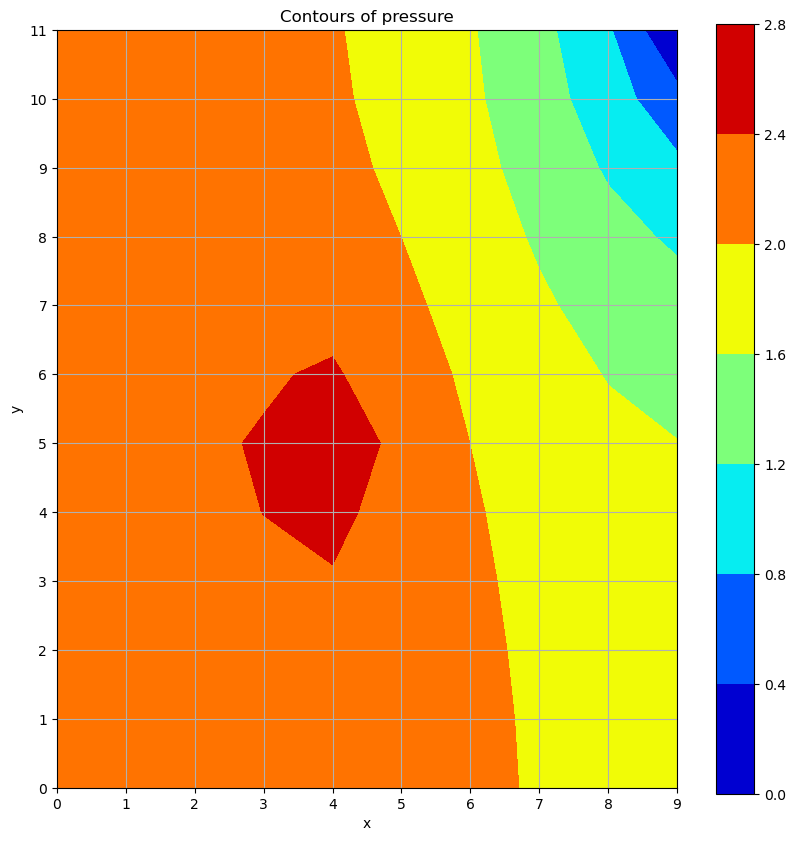

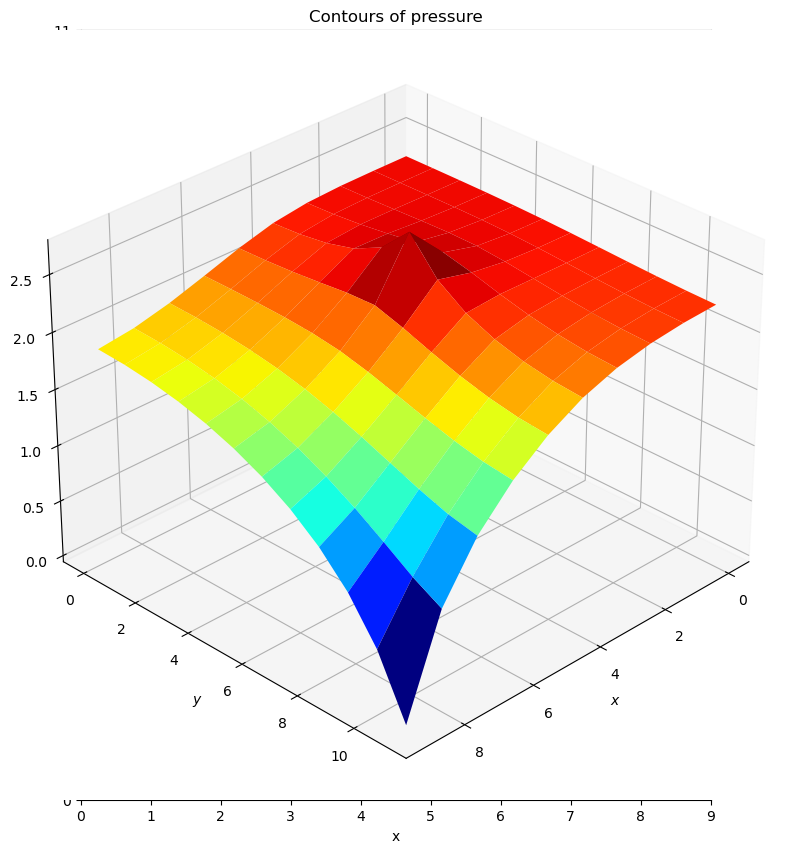

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def GeraRede(nx,ny,CH,CV):
    nv = nx*ny
    nc = (nx-1)*ny + (ny-1)*nx
    
    coord = np.zeros(shape=(nv,2))

    for i in range(nx):
      for j in range(ny):
        ig = i + j*nx
        coord[ig,0] = i
        coord[ig,1] = j

    conec = np.zeros(shape=(nc,2), dtype=int)
    C = np.zeros(nc)
    
    # Loop sobre canos horizontais
    for j in range(ny):
        for i in range(nx-1):
          k = j*(nx-1) + i
          conec[k,0] = j*nx + i
          conec[k,1] = j*nx + i+1
          C[k] = CH

    # Loop sobre canos verticais
    for i in range(nx):
      for j in range(ny-1):
          k = (nx-1)*ny + j*nx + i
          conec[k,0] = i + j*nx
          conec[k,1] = i + (j+1)*nx
          C[k] = CV

    return nv, nc, conec, C, coord

def Assembly(conec, C):
    nv = np.max(conec) + 1 # numero de nós 
    #coloquei +1 pq neste caso, começa em 0
    nc = len(conec[:,0])  # numero de canos
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1,n1] = A[n1,n1] + C[k]
        A[n2,n2] = A[n2,n2] + C[k]
        A[n1,n2] = - C[k]
        A[n2,n1] = - C[k]
    return A

def SolveNetwork(conec, natm, nB, QB, C):
    Atilde = Assembly(conec, C)
    Atilde[natm, :] = 0
    Atilde[natm, natm] = 1
    nv = len(Atilde[0,:])
    b = np.zeros(shape=(nv,1))
    b[nB,0] = QB
    pressure = np.linalg.solve(Atilde, b)
    return pressure.flatten()

def PlotPressure(nx, ny, pressure):
    x = np.arange(0, nx, 1)
    y = np.arange(0, ny, 1)
    X,Y=np.meshgrid(x,y)
    Z = np.copy(pressure)
    Z = Z.reshape((ny, nx))  # Reshape pressure array to match grid dimensions
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set_aspect('equal')
    ax.set(xlabel='x', ylabel='y', title='Contours of pressure')
    ax.grid()
    ax.set_xticks(x)
    ax.set_yticks(y)
    cp = plt.contourf(X, Y, Z, cmap='jet')
    cb = plt.colorbar(cp)
    plt.show()

def PlotPressureAsSurface(nx, ny, pressure):
    x = np.arange(0, nx, 1)
    y = np.arange(0, ny, 1)
    X,Y=np.meshgrid(x,y)
    Z = np.copy(pressure)
    Z.shape = (ny,nx)
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set_aspect('equal')
    ax.set(xlabel='x', ylabel='y', title='Contours of pressure')
    ax.grid()
    ax.set_xticks(x)
    ax.set_yticks(y)
    ax = plt.axes(projection="3d")
    ax.plot_surface(X, Y, Z, cmap='jet', edgecolor=None)
    ax.set(xlabel='$x$', ylabel='$y$', zlabel='$z$')
    ax.view_init(elev=30., azim=45)
    plt.show()
    

CH = 1.3
CV = 3.6
nx, ny = 10, 12
nv, nc, conec, C, coord = GeraRede(nx, ny , CH, CV)
pressao = SolveNetwork(conec, nx*ny -1, 54 , 3, C)
print(pressao)

PlotPressure(nx, ny, pressao)
PlotPressureAsSurface(nx, ny, pressao)

nos [400, 900, 1600, 2500, 3600, 4900, 6400, 8100]

 tempo [0.01011514663696289, 0.021239042282104492, 0.04749751091003418, 0.1738419532775879, 0.4776322841644287, 0.9933021068572998, 2.0992889404296875, 10.428709506988525]


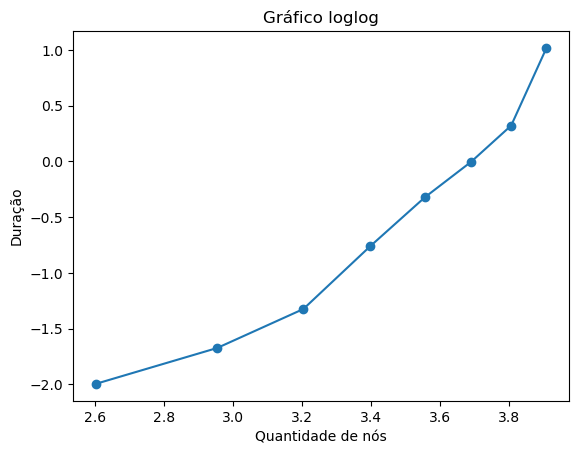

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

def GeraRede(nx,ny,CH,CV):
    nv = nx*ny
    nc = (nx-1)*ny + (ny-1)*nx
    
    coord = np.zeros(shape=(nv,2))

    for i in range(nx):
      for j in range(ny):
        ig = i + j*nx
        coord[ig,0] = i
        coord[ig,1] = j

    conec = np.zeros(shape=(nc,2), dtype=int)
    C = np.zeros(nc)
    
    # Loop sobre canos horizontais
    for j in range(ny):
        for i in range(nx-1):
          k = j*(nx-1) + i
          conec[k,0] = j*nx + i
          conec[k,1] = j*nx + i+1
          C[k] = CH

    # Loop sobre canos verticais
    for i in range(nx):
      for j in range(ny-1):
          k = (nx-1)*ny + j*nx + i
          conec[k,0] = i + j*nx
          conec[k,1] = i + (j+1)*nx
          C[k] = CV

    return nv, nc, conec, C, coord

def Assembly(conec, C):
    nv = np.max(conec) + 1 # numero de nós 
    #coloquei +1 pq neste caso, começa em 0
    nc = len(conec[:,0])  # numero de canos
    A = np.zeros(shape=(nv, nv))
    for k in range(nc):
        n1 = conec[k,0]
        n2 = conec[k,1]
        A[n1,n1] = A[n1,n1] + C[k]
        A[n2,n2] = A[n2,n2] + C[k]
        A[n1,n2] = - C[k]
        A[n2,n1] = - C[k]
    return A

def SolveNetwork(conec, natm, nB, QB, C):
    Atilde = Assembly(conec, C)
    Atilde[natm, :] = 0
    Atilde[natm, natm] = 1
    nv = len(Atilde[0,:])
    b = np.zeros(shape=(nv,1))
    b[nB,0] = QB
    pressure = np.linalg.solve(Atilde, b)
    return pressure

CH = 1
CV = 3
nx, ny = 20, 20
nos = []
tempo = []
qtd = 8
for j in range(qtd):
    ti = time.time()
    nv, nc, conec, C, coord = GeraRede(nx, ny , CH, CV)
    pressao = SolveNetwork(conec, nx*ny -1, 0, 3, C)
    duracao = time.time() - ti     
    nos.append(nx*ny)
    tempo.append(duracao)
    
    nx += 10
    ny += 10

print("nos", nos)
print("\n tempo", tempo)

for i in range(qtd):
    if tempo[i] == 0:
        tempo[i] = 0.0001
X = np.log10(nos)
Y = np.log10(tempo)

plt.plot(X, Y, marker='o')
plt.title('Gráfico loglog')
plt.xlabel('Quantidade de nós')
plt.ylabel('Duração')

plt.show()